# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [ ]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [9]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [10]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [11]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [12]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

In [13]:
# Cargamos el DataFrame desde los archivos Parquet generados
df_resultados = spark.read.parquet("resultados/")

# Mostramos las columnas actuales
print("Columnas del DataFrame:")
print(df_resultados.columns)

Columnas del DataFrame:
['window', 'sensor_id', 'avg_value', 'avg_temp', 'avg_humidity', 'num_events']


### Ejercicio 1

In [14]:
import time
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from pyspark.sql.functions import *

In [15]:
# Mostrar el esquema completo del DataFrame
print("=== ESQUEMA DEL DATAFRAME ===")
df_resultados.printSchema()

=== ESQUEMA DEL DATAFRAME ===
root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)



In [16]:
# Contar el número total de filas
num_filas = df_resultados.count()
print(f"=== NÚMERO TOTAL DE FILAS ===")
print(f"El DataFrame contiene {num_filas} filas")

=== NÚMERO TOTAL DE FILAS ===
El DataFrame contiene 1339 filas


In [17]:
# Contar el número de sensores distintos
num_sensores = df_resultados.select("sensor_id").distinct().count()
print(f"=== SENSORES DISTINTOS ===")
print(f"Aparecen {num_sensores} sensores distintos")

# Mostrar los IDs de los sensores
print("\nLista de sensores:")
df_resultados.select("sensor_id").distinct().show()

=== SENSORES DISTINTOS ===
Aparecen 4 sensores distintos

Lista de sensores:
+---------+
|sensor_id|
+---------+
|       S4|
|       S3|
|       S2|
|       S1|
+---------+



### Ejercicio 2

In [18]:
# Crear una nueva columna: ratio entre temperatura y humedad (temp_humidity_ratio)
# También creamos la diferencia entre avg_temp y avg_humidity
df_transformado = df_resultados.withColumn(
    "temp_humidity_ratio", 
    F.col("avg_temp") / F.col("avg_humidity")
).withColumn(
    "temp_humidity_diff",
    F.col("avg_temp") - F.col("avg_humidity")
)

# Mostrar algunas filas con las nuevas columnas
print("=== DATAFRAME CON NUEVAS COLUMNAS ===")
df_transformado.select("sensor_id", "avg_temp", "avg_humidity", "temp_humidity_ratio", "temp_humidity_diff").show(10)

=== DATAFRAME CON NUEVAS COLUMNAS ===
+---------+------------------+------------------+-------------------+-------------------+
|sensor_id|          avg_temp|      avg_humidity|temp_humidity_ratio| temp_humidity_diff|
+---------+------------------+------------------+-------------------+-------------------+
|       S2|             38.47|            42.215| 0.9112874570650242|-3.7450000000000045|
|       S3|             45.59|           43.5775|  1.046182089380988|  2.012500000000003|
|       S2|53.642999999999994|54.196000000000005| 0.9897962949295149|-0.5530000000000115|
|       S1| 46.39833333333333|              54.5| 0.8513455657492355| -8.101666666666667|
|       S4| 68.19666666666667| 60.98444444444445| 1.1182633094049486|  7.212222222222223|
|       S3| 61.60142857142857|63.892857142857146| 0.9641363890441587|-2.2914285714285754|
|       S1|          56.14875|          59.31375| 0.9466396914712019| -3.164999999999999|
|       S2| 53.61555555555555| 49.39777777777777| 1.0853839578

In [19]:
# Calcular estadísticas de la nueva columna temp_humidity_ratio
print("=== ESTADÍSTICAS DE temp_humidity_ratio ===")
stats_ratio = df_transformado.agg(
    F.min("temp_humidity_ratio").alias("min_ratio"),
    F.max("temp_humidity_ratio").alias("max_ratio"),
    F.avg("temp_humidity_ratio").alias("avg_ratio")
)
stats_ratio.show()

# Calcular estadísticas de temp_humidity_diff
print("=== ESTADÍSTICAS DE temp_humidity_diff ===")
stats_diff = df_transformado.agg(
    F.min("temp_humidity_diff").alias("min_diff"),
    F.max("temp_humidity_diff").alias("max_diff"),
    F.avg("temp_humidity_diff").alias("avg_diff")
)
stats_diff.show()

=== ESTADÍSTICAS DE temp_humidity_ratio ===
+------------------+------------------+-----------------+
|         min_ratio|         max_ratio|        avg_ratio|
+------------------+------------------+-----------------+
|0.3434358367829687|2.8916164891153313|1.015043985526117|
+------------------+------------------+-----------------+

=== ESTADÍSTICAS DE temp_humidity_diff ===
+--------+-----------------+--------------------+
|min_diff|         max_diff|            avg_diff|
+--------+-----------------+--------------------+
|  -48.84|45.38499999999999|-0.36260067347389996|
+--------+-----------------+--------------------+



### Ejercicio 3

In [20]:
# Aplicar filtro con múltiples condiciones:
# - Humedad promedio mayor a 40
# - Número de eventos mayor o igual a 2
# - Sensor S1 o S2

df_filtrado = df_resultados.filter(
    (F.col("avg_humidity") > 40) &
    (F.col("num_events") >= 2) &
    (F.col("sensor_id").isin(["S1", "S2"]))
)

# Contar registros que cumplen las condiciones
num_registros_filtrados = df_filtrado.count()

print("=== FILTRADO AVANZADO ===")
print(f"Condiciones aplicadas:")
print(f"  - avg_humidity > 40")
print(f"  - num_events >= 2")
print(f"  - sensor_id IN ('S1', 'S2')")
print(f"\nNúmero de registros que cumplen TODAS las condiciones: {num_registros_filtrados}")

=== FILTRADO AVANZADO ===
Condiciones aplicadas:
  - avg_humidity > 40
  - num_events >= 2
  - sensor_id IN ('S1', 'S2')

Número de registros que cumplen TODAS las condiciones: 651


In [21]:
# Mostrar algunos de los registros filtrados
print("=== MUESTRA DE REGISTROS FILTRADOS ===")
df_filtrado.show(10)

=== MUESTRA DE REGISTROS FILTRADOS ===
+--------------------+---------+------------------+------------------+------------------+----------+
|              window|sensor_id|         avg_value|          avg_temp|      avg_humidity|num_events|
+--------------------+---------+------------------+------------------+------------------+----------+
|{2026-02-06 10:22...|       S2|             34.26|             38.47|            42.215|         4|
|{2026-02-06 10:37...|       S2|30.077999999999996|53.642999999999994|54.196000000000005|        10|
|{2026-02-06 10:37...|       S1|31.183333333333334| 46.39833333333333|              54.5|         6|
|{2026-02-06 11:22...|       S1|29.012500000000003|          56.14875|          59.31375|         8|
|{2026-02-06 11:22...|       S2| 29.95222222222223| 53.61555555555555| 49.39777777777777|         9|
|{2026-02-06 11:35...|       S1|30.801250000000003|49.933749999999996|          65.14125|         8|
|{2026-02-06 12:12...|       S1| 29.91636363636364| 

### Ejercicio 4

In [22]:
# Agregar estadísticas por sensor
df_stats_sensor = df_resultados.groupBy("sensor_id").agg(
    F.avg("avg_value").alias("media_value"),
    F.avg("avg_temp").alias("media_temp"),
    F.avg("avg_humidity").alias("media_humidity"),
    F.max("avg_temp").alias("max_temp"),
    F.min("avg_temp").alias("min_temp"),
    F.sum("num_events").alias("total_eventos"),
    F.count("*").alias("num_ventanas")
).orderBy(F.desc("media_value"))

print("=== ESTADÍSTICAS POR SENSOR ===")
df_stats_sensor.show()

=== ESTADÍSTICAS POR SENSOR ===
+---------+------------------+------------------+-----------------+--------+------------------+-------------+------------+
|sensor_id|       media_value|        media_temp|   media_humidity|max_temp|          min_temp|total_eventos|num_ventanas|
+---------+------------------+------------------+-----------------+--------+------------------+-------------+------------+
|       S1|30.321102978696256|54.652462700649274|55.12170592276712|  78.626|              21.2|         2456|         335|
|       S4|30.145080190539147| 53.92139328093134|54.87998112376843|   76.54|27.233333333333334|         2451|         335|
|       S2|30.131573364363657| 54.78483642742002| 54.6761469912343|   81.98|            29.462|         2429|         335|
|       S3|29.889713316872747|54.998561771811026|55.12913020337947|  77.904|26.509999999999998|         2356|         334|
+---------+------------------+------------------+-----------------+--------+------------------+------------

In [23]:
# ¿Qué sensor tiene la mayor media en avg_value?
sensor_mayor_media = df_stats_sensor.first()
print(f"=== RESPUESTAS ===")
print(f"Sensor con mayor media de value: {sensor_mayor_media['sensor_id']} (media: {sensor_mayor_media['media_value']:.4f})")

=== RESPUESTAS ===
Sensor con mayor media de value: S1 (media: 30.3211)


In [24]:
# ¿Cuántos grupos o ventanas existen por sensor?
print("\n=== NÚMERO DE VENTANAS POR SENSOR ===")
df_stats_sensor.select("sensor_id", "num_ventanas").show()


=== NÚMERO DE VENTANAS POR SENSOR ===
+---------+------------+
|sensor_id|num_ventanas|
+---------+------------+
|       S1|         335|
|       S4|         335|
|       S2|         335|
|       S3|         334|
+---------+------------+



### Ejercicio 5

In [25]:
# Definir la ventana particionada por sensor, ordenada por avg_value descendente
window_spec = Window.partitionBy("sensor_id").orderBy(F.desc("avg_value"))

# Añadir columna de ranking
df_con_ranking = df_resultados.withColumn("rank", F.row_number().over(window_spec))

# Filtrar solo el registro con mayor avg_value por sensor (rank = 1)
df_max_por_sensor = df_con_ranking.filter(F.col("rank") == 1)

print("=== REGISTRO CON MAYOR avg_value POR SENSOR ===")
df_max_por_sensor.select("sensor_id", "avg_value", "avg_temp", "avg_humidity", "window").show(truncate=False)

=== REGISTRO CON MAYOR avg_value POR SENSOR ===
+---------+-----------------+------------------+------------------+------------------------------------------+
|sensor_id|avg_value        |avg_temp          |avg_humidity      |window                                    |
+---------+-----------------+------------------+------------------+------------------------------------------+
|S1       |43.75333333333333|34.13             |36.52222222222222 |{2026-02-06 09:37:00, 2026-02-06 09:37:30}|
|S2       |45.06400000000001|48.230000000000004|48.84             |{2026-02-06 11:03:30, 2026-02-06 11:04:00}|
|S3       |41.676           |62.55             |43.492000000000004|{2026-02-06 10:30:30, 2026-02-06 10:31:00}|
|S4       |45.46            |76.54             |75.03             |{2026-02-06 11:36:00, 2026-02-06 11:36:30}|
+---------+-----------------+------------------+------------------+------------------------------------------+



In [26]:
# ¿Qué sensor obtiene el valor máximo global entre todos?
sensor_max_global = df_max_por_sensor.orderBy(F.desc("avg_value")).first()
print(f"=== SENSOR CON VALOR MÁXIMO GLOBAL ===")
print(f"Sensor: {sensor_max_global['sensor_id']}")
print(f"Valor máximo (avg_value): {sensor_max_global['avg_value']:.4f}")

=== SENSOR CON VALOR MÁXIMO GLOBAL ===
Sensor: S4
Valor máximo (avg_value): 45.4600


### Ejercicio 6

In [27]:
# Crear DataFrame auxiliar con información adicional de sensores
datos_sensores = [
    ("S1", "Temperatura", "Planta Baja", "Activo"),
    ("S2", "Humedad", "Primer Piso", "Activo"),
    ("S3", "Mixto", "Segundo Piso", "Mantenimiento"),
    ("S4", "Industrial", "Almacén", "Activo")
]

schema_aux = StructType([
    StructField("sensor_id", StringType(), True),
    StructField("tipo", StringType(), True),
    StructField("ubicacion", StringType(), True),
    StructField("estado", StringType(), True)
])

df_info_sensores = spark.createDataFrame(datos_sensores, schema_aux)

print("=== DATAFRAME AUXILIAR DE SENSORES ===")
df_info_sensores.show()

=== DATAFRAME AUXILIAR DE SENSORES ===
+---------+-----------+------------+-------------+
|sensor_id|       tipo|   ubicacion|       estado|
+---------+-----------+------------+-------------+
|       S1|Temperatura| Planta Baja|       Activo|
|       S2|    Humedad| Primer Piso|       Activo|
|       S3|      Mixto|Segundo Piso|Mantenimiento|
|       S4| Industrial|     Almacén|       Activo|
+---------+-----------+------------+-------------+



In [28]:
# Realizar el JOIN entre el DataFrame de resultados y la información auxiliar
df_joined = df_resultados.join(
    df_info_sensores,
    on="sensor_id",
    how="left"
)

print("=== 5 PRIMEROS REGISTROS DEL DATAFRAME UNIDO ===")
df_joined.show(5, truncate=False)

=== 5 PRIMEROS REGISTROS DEL DATAFRAME UNIDO ===
+---------+------------------------------------------+------------------+------------------+------------------+----------+----------+------------+-------------+
|sensor_id|window                                    |avg_value         |avg_temp          |avg_humidity      |num_events|tipo      |ubicacion   |estado       |
+---------+------------------------------------------+------------------+------------------+------------------+----------+----------+------------+-------------+
|S4       |{2026-02-06 11:21:00, 2026-02-06 11:21:30}|34.06666666666667 |68.19666666666667 |60.98444444444445 |9         |Industrial|Almacén     |Activo       |
|S3       |{2026-02-06 10:22:00, 2026-02-06 10:22:30}|35.0525           |45.59             |43.5775           |4         |Mixto     |Segundo Piso|Mantenimiento|
|S3       |{2026-02-06 11:21:00, 2026-02-06 11:21:30}|33.769999999999996|61.60142857142857 |63.892857142857146|7         |Mixto     |Segundo Piso|

### Ejercicio 7

In [29]:
# Extraer el inicio de la ventana y truncar por minuto
df_con_minuto = df_resultados.withColumn(
    "window_start", F.col("window.start")
).withColumn(
    "minuto", F.date_trunc("minute", F.col("window_start"))
)

print("=== DATAFRAME CON MARCA DE MINUTO ===")
df_con_minuto.select("sensor_id", "window", "window_start", "minuto").show(5, truncate=False)

=== DATAFRAME CON MARCA DE MINUTO ===
+---------+------------------------------------------+-------------------+-------------------+
|sensor_id|window                                    |window_start       |minuto             |
+---------+------------------------------------------+-------------------+-------------------+
|S2       |{2026-02-06 10:22:00, 2026-02-06 10:22:30}|2026-02-06 10:22:00|2026-02-06 10:22:00|
|S3       |{2026-02-06 10:22:00, 2026-02-06 10:22:30}|2026-02-06 10:22:00|2026-02-06 10:22:00|
|S2       |{2026-02-06 10:37:00, 2026-02-06 10:37:30}|2026-02-06 10:37:00|2026-02-06 10:37:00|
|S1       |{2026-02-06 10:37:00, 2026-02-06 10:37:30}|2026-02-06 10:37:00|2026-02-06 10:37:00|
|S4       |{2026-02-06 11:21:00, 2026-02-06 11:21:30}|2026-02-06 11:21:00|2026-02-06 11:21:00|
+---------+------------------------------------------+-------------------+-------------------+
only showing top 5 rows



In [30]:
# Agrupar por minuto y calcular estadísticas
df_por_minuto = df_con_minuto.groupBy("minuto").agg(
    F.count("*").alias("num_ventanas"),
    F.avg("avg_humidity").alias("humedad_media"),
    F.avg("avg_temp").alias("temp_media"),
    F.avg("avg_value").alias("value_medio")
).orderBy("minuto")

print("=== ESTADÍSTICAS POR MINUTO ===")
print("¿Cuántas ventanas hay por minuto? y ¿Cuál es la humedad media por minuto?")
df_por_minuto.show(truncate=False)

=== ESTADÍSTICAS POR MINUTO ===
¿Cuántas ventanas hay por minuto? y ¿Cuál es la humedad media por minuto?
+-------------------+------------+------------------+------------------+------------------+
|minuto             |num_ventanas|humedad_media     |temp_media        |value_medio       |
+-------------------+------------+------------------+------------------+------------------+
|2026-02-06 09:35:00|4           |59.652027777777775|48.86436111111111 |29.43875          |
|2026-02-06 09:36:00|8           |52.59951731601731 |50.9059816017316  |28.02524242424242 |
|2026-02-06 09:37:00|8           |55.29046356421357 |53.81301902958154 |31.695897005772004|
|2026-02-06 09:38:00|8           |53.36201681998557 |57.05747970779221 |32.0461167478355  |
|2026-02-06 09:39:00|8           |52.80585795454546 |52.285559659090914|31.459952651515152|
|2026-02-06 09:40:00|8           |55.800858630952376|53.80430952380953 |29.54095089285714 |
|2026-02-06 09:41:00|8           |54.007749503968256|59.2301314484

### Ejercicio 8

In [31]:
# Reparticionar por sensor_id (4 particiones, una por sensor)
df_reparticionado = df_resultados.repartition(4, "sensor_id")

# Añadir columna con el identificador de partición
df_con_particion = df_reparticionado.withColumn(
    "partition_id", F.spark_partition_id()
)

print("=== DATAFRAME CON ID DE PARTICIÓN ===")
df_con_particion.select("sensor_id", "avg_value", "partition_id").show(10)

=== DATAFRAME CON ID DE PARTICIÓN ===
+---------+------------------+------------+
|sensor_id|         avg_value|partition_id|
+---------+------------------+------------+
|       S3|           35.0525|           0|
|       S3|33.769999999999996|           0|
|       S3|24.819999999999997|           0|
|       S3|             33.38|           0|
|       S3|            32.962|           0|
|       S3| 30.04636363636364|           0|
|       S3|27.065714285714282|           0|
|       S3|23.783636363636365|           0|
|       S3|40.730000000000004|           0|
|       S3| 33.10333333333333|           0|
+---------+------------------+------------+
only showing top 10 rows



In [32]:
# Distribución de registros entre particiones
print("=== DISTRIBUCIÓN DE REGISTROS POR PARTICIÓN ===")
df_distribucion = df_con_particion.groupBy("partition_id").agg(
    F.count("*").alias("num_registros"),
    F.collect_set("sensor_id").alias("sensores_en_particion")
).orderBy("partition_id")

df_distribucion.show(truncate=False)

=== DISTRIBUCIÓN DE REGISTROS POR PARTICIÓN ===
+------------+-------------+---------------------+
|partition_id|num_registros|sensores_en_particion|
+------------+-------------+---------------------+
|0           |334          |[S3]                 |
|1           |670          |[S2, S4]             |
|3           |335          |[S1]                 |
+------------+-------------+---------------------+



### Ejercicio 9

In [33]:
# Calcular media y desviación estándar de avg_value para definir anomalías
stats = df_resultados.agg(
    F.avg("avg_value").alias("mean_value"),
    F.stddev("avg_value").alias("std_value"),
    F.avg("avg_temp").alias("mean_temp"),
    F.stddev("avg_temp").alias("std_temp")
).collect()[0]

mean_value = stats["mean_value"]
std_value = stats["std_value"]
mean_temp = stats["mean_temp"]
std_temp = stats["std_temp"]

print(f"=== ESTADÍSTICAS PARA DETECCIÓN DE ANOMALÍAS ===")
print(f"Media de avg_value: {mean_value:.4f}")
print(f"Desviación estándar de avg_value: {std_value:.4f}")
print(f"Media de avg_temp: {mean_temp:.4f}")
print(f"Desviación estándar de avg_temp: {std_temp:.4f}")

=== ESTADÍSTICAS PARA DETECCIÓN DE ANOMALÍAS ===
Media de avg_value: 30.1220
Desviación estándar de avg_value: 4.7281
Media de avg_temp: 54.5890
Desviación estándar de avg_temp: 8.1059


In [34]:
# Definir anomalía: valor fuera de 2 desviaciones estándar de la media
# o temperatura extrema (fuera de 1.5 std)
df_con_anomalias = df_resultados.withColumn(
    "es_anomalia",
    F.when(
        (F.abs(F.col("avg_value") - mean_value) > 2 * std_value) |
        (F.abs(F.col("avg_temp") - mean_temp) > 1.5 * std_temp),
        True
    ).otherwise(False)
)

# Contar registros anómalos
num_anomalias = df_con_anomalias.filter(F.col("es_anomalia") == True).count()
total_registros = df_con_anomalias.count()

print(f"=== DETECCIÓN DE ANOMALÍAS ===")
print(f"Criterio: |avg_value - media| > 2*std OR |avg_temp - media| > 1.5*std")
print(f"\nTotal de registros: {total_registros}")
print(f"Registros anómalos: {num_anomalias}")
print(f"Porcentaje de anomalías: {(num_anomalias/total_registros)*100:.2f}%")

=== DETECCIÓN DE ANOMALÍAS ===
Criterio: |avg_value - media| > 2*std OR |avg_temp - media| > 1.5*std

Total de registros: 1339
Registros anómalos: 228
Porcentaje de anomalías: 17.03%


In [35]:
# ¿Qué sensor tiene más anomalías?
df_anomalias_sensor = df_con_anomalias.filter(F.col("es_anomalia") == True).groupBy("sensor_id").agg(
    F.count("*").alias("num_anomalias")
).orderBy(F.desc("num_anomalias"))

print("=== ANOMALÍAS POR SENSOR ===")
df_anomalias_sensor.show()

sensor_mas_anomalias = df_anomalias_sensor.first()
if sensor_mas_anomalias:
    print(f"\nSensor con más anomalías: {sensor_mas_anomalias['sensor_id']} ({sensor_mas_anomalias['num_anomalias']} anomalías)")

=== ANOMALÍAS POR SENSOR ===
+---------+-------------+
|sensor_id|num_anomalias|
+---------+-------------+
|       S4|           62|
|       S3|           56|
|       S1|           56|
|       S2|           54|
+---------+-------------+


Sensor con más anomalías: S4 (62 anomalías)


### Ejercicio 10

In [36]:
# Crear puntuación ponderada:
# score = 0.5 * avg_value + 0.3 * avg_temp + 0.2 * avg_humidity
# Normalizamos primero para que las escalas sean comparables

# Obtener min/max para normalización
min_max = df_resultados.agg(
    F.min("avg_value").alias("min_value"), F.max("avg_value").alias("max_value"),
    F.min("avg_temp").alias("min_temp"), F.max("avg_temp").alias("max_temp"),
    F.min("avg_humidity").alias("min_hum"), F.max("avg_humidity").alias("max_hum")
).collect()[0]

# Crear columnas normalizadas y puntuación
df_con_score = df_resultados.withColumn(
    "norm_value", 
    (F.col("avg_value") - min_max["min_value"]) / (min_max["max_value"] - min_max["min_value"])
).withColumn(
    "norm_temp",
    (F.col("avg_temp") - min_max["min_temp"]) / (min_max["max_temp"] - min_max["min_temp"])
).withColumn(
    "norm_humidity",
    (F.col("avg_humidity") - min_max["min_hum"]) / (min_max["max_hum"] - min_max["min_hum"])
).withColumn(
    "score",
    0.5 * F.col("norm_value") + 0.3 * F.col("norm_temp") + 0.2 * F.col("norm_humidity")
)

print("=== DATAFRAME CON PUNTUACIÓN ===")
print("Score = 0.5 * norm_value + 0.3 * norm_temp + 0.2 * norm_humidity")
df_con_score.select("sensor_id", "avg_value", "avg_temp", "avg_humidity", "score").show(10)

=== DATAFRAME CON PUNTUACIÓN ===
Score = 0.5 * norm_value + 0.3 * norm_temp + 0.2 * norm_humidity
+---------+------------------+------------------+------------------+------------------+
|sensor_id|         avg_value|          avg_temp|      avg_humidity|             score|
+---------+------------------+------------------+------------------+------------------+
|       S2|             34.26|             38.47|            42.215|0.4800101557415998|
|       S3|           35.0525|             45.59|           43.5775| 0.532115151696903|
|       S2|30.077999999999996|53.642999999999994|54.196000000000005| 0.530040676508323|
|       S1|31.183333333333334| 46.39833333333333|              54.5| 0.512556597309092|
|       S4| 34.06666666666667| 68.19666666666667| 60.98444444444445|0.6870116710545123|
|       S3|33.769999999999996| 61.60142857142857|63.892857142857146|0.6596365351570231|
|       S1|29.012500000000003|          56.14875|          59.31375|0.5430386194156402|
|       S2| 29.9522222

In [37]:
# Puntuación media por sensor
df_score_sensor = df_con_score.groupBy("sensor_id").agg(
    F.avg("score").alias("score_medio"),
    F.max("score").alias("score_max")
).orderBy(F.desc("score_medio"))

print("=== PUNTUACIÓN POR SENSOR ===")
df_score_sensor.show()

# Sensor con mayor puntuación media
mejor_sensor = df_score_sensor.first()
print(f"\n=== RESPUESTA ===")
print(f"Sensor con puntuación más alta (media): {mejor_sensor['sensor_id']}")
print(f"Valor de la puntuación media: {mejor_sensor['score_medio']:.4f}")
print(f"Puntuación máxima alcanzada: {mejor_sensor['score_max']:.4f}")

=== PUNTUACIÓN POR SENSOR ===
+---------+------------------+------------------+
|sensor_id|       score_medio|         score_max|
+---------+------------------+------------------+
|       S1|0.5419385434826633| 0.791680167834089|
|       S2|0.5381317402497433|0.9250208626723393|
|       S3|0.5369398182043792|0.7787606404498292|
|       S4|0.5347680604111525|0.9533547610618527|
+---------+------------------+------------------+


=== RESPUESTA ===
Sensor con puntuación más alta (media): S1
Valor de la puntuación media: 0.5419
Puntuación máxima alcanzada: 0.7917


### Ejercicio 11

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir DataFrame de Spark a Pandas
df_pandas = df_resultados.toPandas()

print(f"DataFrame convertido a Pandas: {len(df_pandas)} registros")
df_pandas.head()

DataFrame convertido a Pandas: 1339 registros


,window,sensor_id,avg_value,avg_temp,avg_humidity,num_events
0,"(2026-02-06 10:22:00, 2026-02-06 10:22:30)",S2,34.260000,38.470000,42.215000,4
1,"(2026-02-06 10:22:00, 2026-02-06 10:22:30)",S3,35.052500,45.590000,43.577500,4
2,"(2026-02-06 10:37:00, 2026-02-06 10:37:30)",S2,30.078000,53.643000,54.196000,10
3,"(2026-02-06 10:37:00, 2026-02-06 10:37:30)",S1,31.183333,46.398333,54.500000,6
4,"(2026-02-06 11:21:00, 2026-02-06 11:21:30)",S4,34.066667,68.196667,60.984444,9


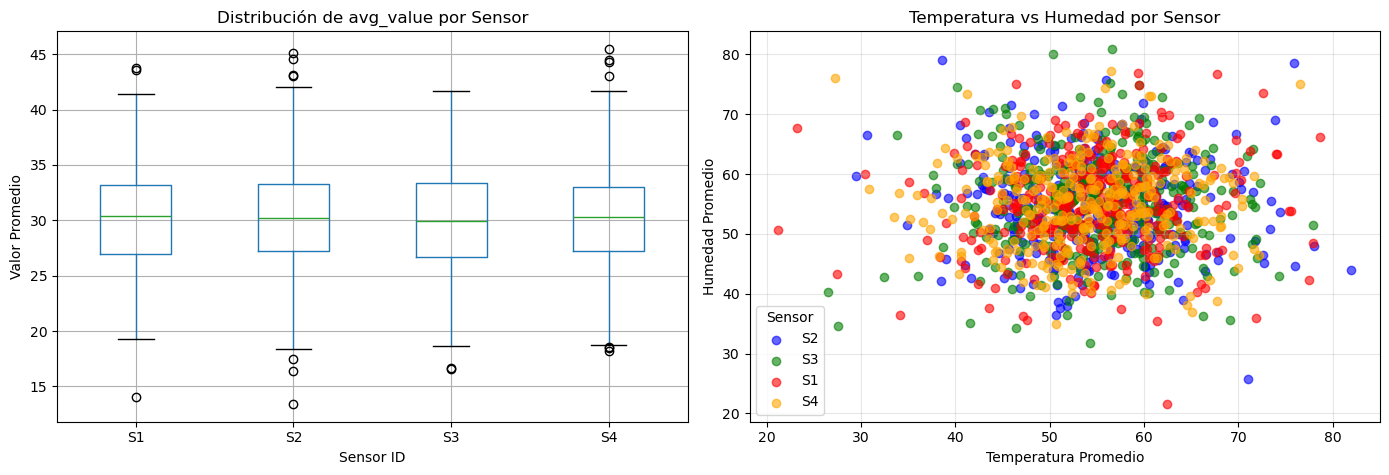


✅ Gráficos guardados como 'graficos_sensores.png'


In [39]:
# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Boxplot de avg_value por sensor
ax1 = axes[0]
df_pandas.boxplot(column='avg_value', by='sensor_id', ax=ax1)
ax1.set_title('Distribución de avg_value por Sensor')
ax1.set_xlabel('Sensor ID')
ax1.set_ylabel('Valor Promedio')
plt.suptitle('')  # Eliminar título automático del boxplot

# Gráfico 2: Scatter plot de temperatura vs humedad
ax2 = axes[1]
colors = {'S1': 'red', 'S2': 'blue', 'S3': 'green', 'S4': 'orange'}
for sensor in df_pandas['sensor_id'].unique():
    subset = df_pandas[df_pandas['sensor_id'] == sensor]
    ax2.scatter(subset['avg_temp'], subset['avg_humidity'], 
                label=sensor, alpha=0.6, c=colors.get(sensor, 'gray'))

ax2.set_title('Temperatura vs Humedad por Sensor')
ax2.set_xlabel('Temperatura Promedio')
ax2.set_ylabel('Humedad Promedio')
ax2.legend(title='Sensor')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficos_sensores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráficos guardados como 'graficos_sensores.png'")

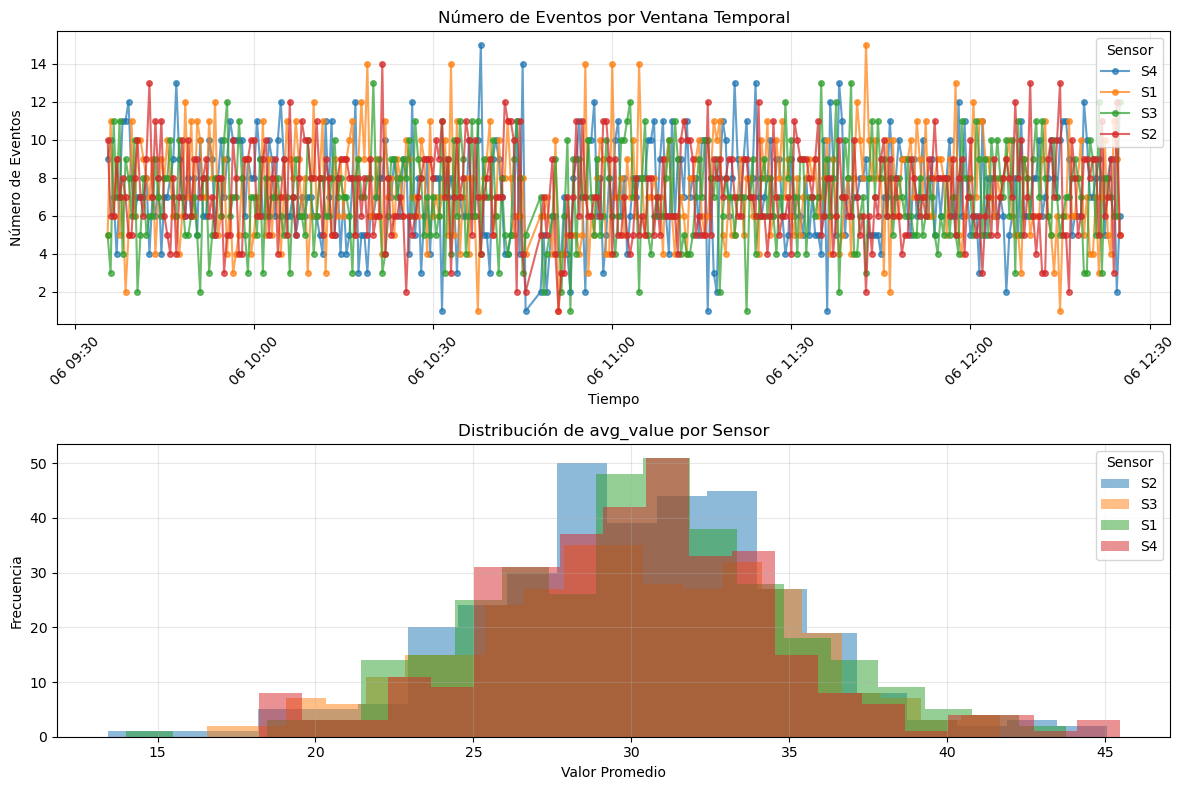


✅ Gráficos temporales guardados como 'graficos_temporales.png'


In [40]:
# Gráfico adicional: Evolución temporal de las métricas
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Extraer start de la ventana para el eje temporal
df_pandas['window_start'] = df_pandas['window'].apply(lambda x: x['start'])
df_pandas_sorted = df_pandas.sort_values('window_start')

# Gráfico 1: Número de eventos por ventana temporal
ax1 = axes[0]
for sensor in df_pandas_sorted['sensor_id'].unique():
    subset = df_pandas_sorted[df_pandas_sorted['sensor_id'] == sensor]
    ax1.plot(subset['window_start'], subset['num_events'], 
             marker='o', label=sensor, alpha=0.7, markersize=4)

ax1.set_title('Número de Eventos por Ventana Temporal')
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Número de Eventos')
ax1.legend(title='Sensor')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Histograma de avg_value
ax2 = axes[1]
for sensor in df_pandas['sensor_id'].unique():
    subset = df_pandas[df_pandas['sensor_id'] == sensor]
    ax2.hist(subset['avg_value'], bins=20, alpha=0.5, label=sensor)

ax2.set_title('Distribución de avg_value por Sensor')
ax2.set_xlabel('Valor Promedio')
ax2.set_ylabel('Frecuencia')
ax2.legend(title='Sensor')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficos_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráficos temporales guardados como 'graficos_temporales.png'")